In [1]:
import pandas as pd 
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt 
from sklearn.metrics import r2_score
from jax import random
import numpy as np

In [2]:
from sklearn.model_selection import train_test_split

key = random.PRNGKey(1)
key2 = random.PRNGKey(2)

X = random.normal(key,shape=(1000,1))
y = 2*(X**3) + 10 + 4.6*random.normal(key2,(1000,1))
X, X_test, y, y_test = train_test_split(X, y)


In [3]:
@jax.jit
def wm(point, X, tau):
    m = X.shape[0]
    
    w = np.mat(np.eye(m))
    w = jnp.array(w)
    
    for i in range(m):
        xi = X[i]
        d = (-2 ** tau)
        w = jax.ops.index_update(w,jax.ops.index[i,i],jnp.exp(jnp.dot((xi-point),(xi-point).T)/d))
        
    return w

In [4]:
@jax.jit
def predict(X, y, point, tau):
    m = X.shape[0]
    
    X_ = jnp.append(X, jnp.ones(m).reshape(m,1), axis=1)
    
    point_ = jnp.array([point, 1])
    
    w = wm(point_, X_, tau)
    
    theta = jnp.linalg.pinv(X_.T.dot(w.dot(X_))).dot(X_.T.dot(w.dot(y))) 
    
    pred = jnp.dot(point_, theta)
    
    return theta, pred


In [5]:

def plot_predictions(X, Y, tau, nval):
    
    X_test = jnp.linspace(-3, 3, nval)
    
    preds = []
    for point in X_test:
        theta, pred = predict(X, y, point, tau)
        preds.append(pred)
    X_test = jnp.array(X_test).reshape(nval,1)
    preds = jnp.array(preds).reshape(nval,1)
    
    plt.plot(X, y, 'b.')
    plt.plot(X_test, preds, 'r.')
    plt.show()

a
aa


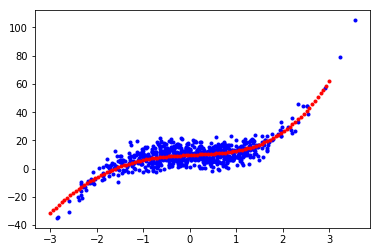

In [7]:
plot_predictions(X, y, 0.001, 100)